# Ping Pong Ball Prediction Using Transfer Learning:

Inputs:
- x y z (frame 1)
- x y z (frame 2)
- x y z (frame 3)
- x y z (frame 4)
- x y z (frame 5)
- x y z (frame 6)
- dt12
- dt23
- dt34
- dt45
- dt56


Outputs:
- x y z (interception)
- vx vy vz
- t_hit



## Importing the Libraries

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

### Importing the Dataset

In [2]:
synthetic_dataset_path = '../learning_data/synthetic_data/synthetic_intercept_dataset_70.csv'
dataset = pd.read_csv(synthetic_dataset_path)
print('Using synthetic dataset:', synthetic_dataset_path)




Using synthetic dataset: ../learning_data/synthetic_data/synthetic_intercept_dataset_70.csv


In [3]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 41 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   x1                     20000 non-null  float64
 1   y1                     20000 non-null  float64
 2   z1                     20000 non-null  float64
 3   x2                     20000 non-null  float64
 4   y2                     20000 non-null  float64
 5   z2                     20000 non-null  float64
 6   x3                     20000 non-null  float64
 7   y3                     20000 non-null  float64
 8   z3                     20000 non-null  float64
 9   x4                     20000 non-null  float64
 10  y4                     20000 non-null  float64
 11  z4                     20000 non-null  float64
 12  x5                     20000 non-null  float64
 13  y5                     20000 non-null  float64
 14  z5                     20000 non-null  float64
 15  x6

In [4]:
dataset.describe()

,x1,y1,z1,x2,y2,z2,x3,y3,z3,x4,...,bounces_before_hit,has_bounce_before_hit,intercept_valid,x0,y0,z0,vx0,vy0,vz0,gravity_z_mm_s2
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,...,20000.000000,20000.000000,20000.0,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,-1.339049,2203.586630,-877.583886,-1.054894,2134.673705,-873.419250,-0.858897,2065.751624,-866.701637,-0.473129,...,1.251800,0.980700,1.0,-3.555290,2701.507604,-802.872811,17.049800,-4271.521275,-1485.893304,-9810.242357
std,456.306760,201.604991,165.661723,442.644894,212.744226,167.493339,430.120098,224.710545,171.552756,418.847040,...,0.476454,0.137581,0.0,584.717647,157.737503,188.447141,1630.148954,1126.616220,1660.179677,49.010996
min,-799.961743,1600.135373,-1121.043880,-823.774743,1484.292742,-1123.516723,-836.497214,1356.343191,-1124.643861,-844.183416,...,0.000000,0.000000,1.0,-1062.142610,2450.018192,-1109.978151,-4978.077499,-7664.693198,-5461.122042,-9995.623185
25%,-389.896077,2086.236518,-1011.940458,-377.125630,2012.306610,-1010.260756,-362.601183,1935.355116,-1006.857728,-348.988469,...,1.000000,1.000000,1.0,-508.474772,2565.753767,-959.391824,-998.360806,-5070.735911,-2704.938759,-9843.343842
50%,-3.645759,2263.468909,-911.090996,-2.051878,2196.722559,-906.713056,-2.610234,2128.801441,-901.430906,-0.240149,...,1.000000,1.000000,1.0,0.054000,2690.314689,-826.793136,12.176528,-4103.468482,-1380.761818,-9809.740122
75%,384.068485,2368.481873,-770.451513,370.179060,2307.096127,-762.575734,359.439162,2245.839892,-751.908432,348.732400,...,2.000000,1.000000,1.0,495.314177,2824.599037,-656.666080,1040.324403,-3390.508082,-232.511549,-9776.927599
max,799.899556,2429.995101,-410.487007,822.021552,2403.067286,-350.552969,830.928838,2372.606247,-309.335154,856.195219,...,2.000000,1.000000,1.0,1062.379353,3127.474310,-410.048376,5119.895506,-1782.255395,2474.356579,-9603.020698


### Pre-Processing

### Separating the Input and Outputs

In [5]:

input_cols_6 = [
    "x1", "y1", "z1",
    "x2", "y2", "z2",
    "x3", "y3", "z3",
    "x4", "y4", "z4",
    "x5", "y5", "z5",
    "x6", "y6", "z6",
    "dt12", "dt23", "dt34", "dt45", "dt56",
]
target_cols = ["x_hit", "y_hit", "z_hit", "vx_hit", "vy_hit", "vz_hit", "t_hit"]

x = dataset[input_cols_6]
y = dataset[target_cols]


In [6]:
# View the inputs
print(x)

               x1           y1           z1          x2           y2  \
0     -705.111897  2417.130082  -581.363406 -681.724603  2375.230548   
1      420.691725  1971.800258 -1003.892873  433.849105  1914.777219   
2     -609.028122  2426.370452  -982.912409 -623.072074  2368.350726   
3      155.670559  2194.897294  -576.246119  114.404209  2141.931907   
4      -19.299076  1990.005137 -1054.893700  -30.880989  1920.513947   
...           ...          ...          ...         ...          ...   
19995 -245.923648  2092.872927 -1070.358096 -250.190236  2053.267274   
19996  126.929926  2204.734092  -712.619456   94.688112  2127.518402   
19997 -193.188651  2268.340292  -835.759736 -154.941724  2226.870327   
19998 -712.940639  2128.839267 -1050.459609 -672.108148  2065.408784   
19999 -120.861255  2395.524215 -1111.791583 -121.249559  2333.795104   

                z2          x3           y3           z3          x4  ...  \
0      -578.541098 -672.852777  2323.498216  -586.696949 -

In [7]:
# View the outputs
print(y)

             x_hit        y_hit       z_hit       vx_hit       vy_hit  \
0       181.143112    58.771577 -575.800214  1376.436575 -3673.476952   
1       310.529769     9.197282 -329.571217  -308.572302 -4935.690435   
2     -1479.910550   344.429971 -572.956072 -1327.755836 -3169.739257   
3     -1014.192835  1343.972303 -949.602869 -3862.697165 -2799.125066   
4      -313.759981   364.624656  -22.440909  -821.904332 -4723.926473   
...            ...          ...         ...          ...          ...   
19995   224.623472    53.286435 -869.704026   708.162784 -3039.154323   
19996  -459.729702   -50.324652 -802.537698 -1179.685122 -4617.235644   
19997   608.632842   -17.107670 -805.956907  1318.115807 -3809.503151   
19998   489.740459   -24.414074 -807.140563  1917.462465 -3437.013324   
19999  -419.321843    45.799597 -934.964048  -574.418761 -4305.756995   

            vz_hit     t_hit  
0       -81.077668  0.560320  
1       288.623782  0.319429  
2     -2599.911467  0.573112  

In [8]:
x = x.values
y = y.values

### Splitting the Dataset into the Training set and Test set

In [9]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1) Build reachability vector from your full dataset
# (change column name if needed)
r = dataset["is_reachable"].to_numpy().astype(int)

# 2) Split x, y, and r together (important)
x_train, x_test, y_train, y_test, r_train, r_test = train_test_split(
    x, y, r,
    test_size=0.05,
    random_state=1,
    stratify=r   # recommended
)

# 3) Keep full test copy
x_test_all = x_test.copy()
y_test_all = y_test.copy()

# 4) Reachable-only adjusted test set
mask_reach = (r_test == 1)
x_test_reach = x_test_all[mask_reach].copy()
y_test_reach = y_test_all[mask_reach].copy()


In [10]:
print(x_train.shape)
print(x_test_all.shape)
print(x_test_reach.shape)
print(y_train.shape)
print(y_test_all.shape)
print(y_test_reach.shape)

(19000, 23)
(1000, 23)
(700, 23)
(19000, 7)
(1000, 7)
(700, 7)


### Feature Scaling

In [11]:
from sklearn.preprocessing import StandardScaler

scx = StandardScaler()
scy = StandardScaler()

x_train = scx.fit_transform(x_train)
x_test_all = scx.transform(x_test_all)
x_test_reach = scx.transform(x_test_reach)

y_train = scy.fit_transform((y_train))
y_test_all = scy.transform((y_test_all))
y_test_reach = scy.transform((y_test_reach))

In [12]:
# --- weighted loss + sample weighting helpers (xyz emphasis + center/reach emphasis) ---
import tensorflow as tf
import numpy as np

@tf.keras.utils.register_keras_serializable(package="Custom")
def weighted_mse(y_true, y_pred):
    raw_w = tf.constant([1,1,1,0,0,0,0], tf.float32)
    w = raw_w / tf.reduce_mean(raw_w)
    err2 = tf.square(y_true - y_pred)
    return tf.reduce_mean(err2 * w, axis=-1)  # per-sample loss



WORKSPACE_CENTER_MM = np.array([0.0, 0.0, -900.0], dtype=np.float32)
CENTER_SIGMA_MM = 250.0
REACH_BOOST = 1.0
CENTER_BOOST = 2.0

def build_sample_weights(y_train_scaled, y_scaler, reachable_vec=None,
                         center=WORKSPACE_CENTER_MM,
                         sigma_mm=CENTER_SIGMA_MM,
                         reach_boost=REACH_BOOST,
                         center_boost=CENTER_BOOST):
    y_u = y_scaler.inverse_transform(y_train_scaled)
    d_mm = np.linalg.norm(y_u[:, :3] - center[None, :], axis=1)

    w_center = 1.0 + center_boost * np.exp(-(d_mm ** 2) / (2.0 * sigma_mm ** 2))
    if reachable_vec is None:
        w_reach = np.ones_like(w_center)
    else:
        w_reach = 1.0 + reach_boost * np.asarray(reachable_vec, dtype=float)

    w = w_center * w_reach
    w = w / np.mean(w)
    return np.clip(w, 0.5, 5.0)

# Broad-stage sample weights (r_train comes from the broad train/test split cell)
sample_w_broad = build_sample_weights(y_train, scy, reachable_vec=r_train)
print("sample_w_broad stats:", sample_w_broad.min(), sample_w_broad.mean(), sample_w_broad.max())


sample_w_broad stats: 0.5 1.0389965744310063 2.143109249345195


## The ANN Model Initialization

In [13]:
ball_predictor = tf.keras.models.Sequential()

### Constructing the Model

In [14]:

ball_predictor.add(tf.keras.layers.Dense(units=23, activation='relu')) # 23 input features (6 points + 5 dt)
ball_predictor.add(tf.keras.layers.Dense(units=32, activation='relu')) # hiddel layer 1
ball_predictor.add(tf.keras.layers.Dense(units=64, activation='relu')) # hidden layer 2
ball_predictor.add(tf.keras.layers.Dense(units=64, activation='relu')) # hiddel layer 3
ball_predictor.add(tf.keras.layers.Dense(units=32, activation='relu')) # hiddel layer 3
ball_predictor.add(tf.keras.layers.Dense(units=7, activation='linear')) # 7


In [15]:
ball_predictor.compile(
    loss=weighted_mse,
    optimizer='adam',
    metrics=['mean_squared_error']
)


### Training

In [16]:
p1 = ball_predictor.fit(
    x_train,
    y_train,
    sample_weight=sample_w_broad,
    validation_split=0.2,
    batch_size=32,
    epochs=60,
    verbose=1,
)


Epoch 1/60
475/475 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.5388 - mean_squared_error: 0.9634 - val_loss: 0.3815 - val_mean_squared_error: 0.9501
Epoch 2/60
475/475 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2517 - mean_squared_error: 0.9290 - val_loss: 0.1923 - val_mean_squared_error: 0.9291
Epoch 3/60
475/475 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1715 - mean_squared_error: 0.9127 - val_loss: 0.1548 - val_mean_squared_error: 0.9234
Epoch 4/60
475/475 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1352 - mean_squared_error: 0.9052 - val_loss: 0.1173 - val_mean_squared_error: 0.9229
Epoch 5/60
475/475 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1030 - mean_squared_error: 0.8945 - val_loss: 0.0984 - val_mean_squared_error: 0.9254
Epoch 6/60
475/475 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0867 - mean_squared_error: 0.8824 - val_loss: 0.0943 - val_mean_squared_error: 0.9103
Epoch 7/60
475/475 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0773 - mean_squared_error: 0.8784 - val_loss: 0.07

### Learning Curves

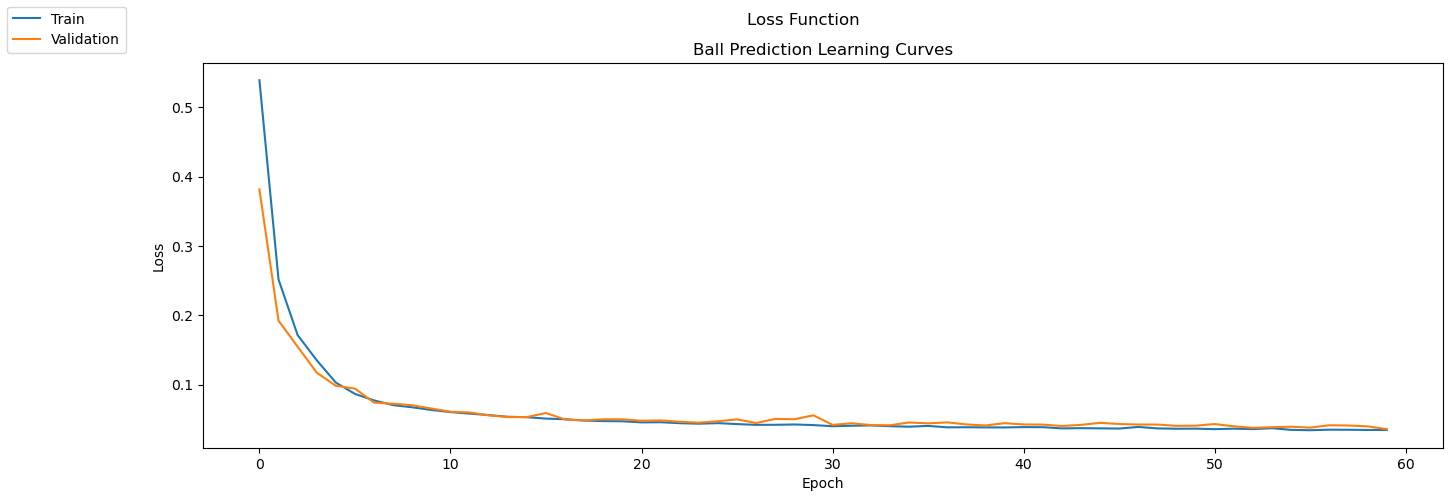

In [17]:
fig, axs = plt.subplots(figsize=(16,5))
fig.suptitle('Loss Function')

axs.plot(p1.history['loss'])
axs.plot(p1.history['val_loss'])
axs.set_title("Ball Prediction Learning Curves")
axs.set(xlabel='Epoch', ylabel='Loss')

fig.legend(labels=['Train', 'Validation'], loc="upper left")
plt.show()

In [18]:
# def eval_regression(name, y_true, y_pred):
#     mae = mean_absolute_error(y_true, y_pred, multioutput='raw_values')
#     rmse = np.sqrt(mean_squared_error(y_true, y_pred, multioutput='raw_values'))
#     print(f"\n{name}")
#     print("MAE per output:", mae)
#     print("RMSE per output:", rmse)

# # If y is scaled, inverse-transform both y_true and y_pred before metrics.
# y_pred_all = ball_predictor.predict(x_test_all)
# y_pred_reach = ball_predictor.predict(x_test_reach)

# # Example for scaled targets:
# # y_pred_all = scy.inverse_transform(y_pred_all); y_test_all_eval = scy.inverse_transform(y_test_all)
# # y_pred_reach = scy.inverse_transform(y_pred_reach); y_test_reach_eval = scy.inverse_transform(y_test_reach)

# eval_regression("All test shots", y_test_all, y_pred_all)
# eval_regression("Reachable-only test shots", y_test_reach, y_pred_reach)

import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error

target_names = ["x_hit", "y_hit", "z_hit", "vx_hit", "vy_hit", "vz_hit", "t_hit"]
target_units = ["mm", "mm", "mm", "mm/s", "mm/s", "mm/s", "ms"]

def eval_with_units(name, model, x_eval, y_eval, y_scaler, y_is_scaled=True, t_hit_in_seconds=True):
    y_pred = model.predict(x_eval, verbose=0)

    # Convert to physical units exactly once
    if y_is_scaled:
        assert y_eval.shape[1] == y_scaler.n_features_in_ == len(target_names)
        y_true_u = y_scaler.inverse_transform(y_eval)
        y_pred_u = y_scaler.inverse_transform(y_pred)
    else:
        y_true_u = y_eval
        y_pred_u = y_pred

    err = y_pred_u - y_true_u
    abs_err = np.abs(err)

    mae = mean_absolute_error(y_true_u, y_pred_u, multioutput="raw_values")
    rmse = np.sqrt(mean_squared_error(y_true_u, y_pred_u, multioutput="raw_values"))
    std_abs = abs_err.std(axis=0)

    # Convert t_hit to ms for reporting (only if stored in seconds)
    if t_hit_in_seconds:
        i = target_names.index("t_hit")
        mae[i] *= 1000.0
        rmse[i] *= 1000.0
        std_abs[i] *= 1000.0

    report = pd.DataFrame({
        "target": target_names,
        "unit": target_units,
        "MAE": mae,
        "RMSE": rmse,
        "STD_abs_error": std_abs,
    })

    print(f"\n{name}")
    print(report.to_string(index=False, float_format=lambda v: f"{v:,.3f}"))

# Run both:
eval_with_units("All test shots", ball_predictor, x_test_all, y_test_all, scy, y_is_scaled=True, t_hit_in_seconds=True)
eval_with_units("Reachable-only test shots", ball_predictor, x_test_reach, y_test_reach, scy, y_is_scaled=True, t_hit_in_seconds=True)




All test shots
target unit       MAE      RMSE  STD_abs_error
 x_hit   mm    58.827    79.791         53.907
 y_hit   mm    67.915   110.007         86.540
 z_hit   mm    36.330    56.081         42.722
vx_hit mm/s 1,844.360 2,496.173      1,682.027
vy_hit mm/s   783.898 1,017.598        648.852
vz_hit mm/s 2,182.316 2,498.024      1,215.573
 t_hit   ms   197.940   249.477        151.850

Reachable-only test shots
target unit       MAE      RMSE  STD_abs_error
 x_hit   mm    56.495    73.798         47.482
 y_hit   mm    60.330    88.181         64.313
 z_hit   mm    23.659    31.894         21.389
vx_hit mm/s 1,329.814 1,658.769        991.519
vy_hit mm/s   830.116 1,083.360        696.115
vz_hit mm/s 2,274.948 2,569.868      1,195.338
 t_hit   ms   211.796   265.165        159.546


In [19]:
# Verification 
train_std = scy.scale_ 
rmse_sigma = np.sqrt(0.1084)   # val_mse from curve, e.g. 0.1151
rmse_units = rmse_sigma * train_std

print(rmse_units)


[1.77979691e+02 1.11748760e+02 9.59219570e+01 5.37080050e+02
 3.70565393e+02 6.86117988e+02 6.09266036e-02]


## Loading the Matched Synthetic Dataset (Transfer Learning)

In [20]:
# matched_dataset = pd.read_csv('../learning_data/synthetic_matched_data/synthetic_intercept_dataset.csv')
# matched_dataset.info()

In [21]:
# input_cols_6 = [
#     "x1", "y1", "z1",
#     "x2", "y2", "z2",
#     "x3", "y3", "z3",
#     "x4", "y4", "z4",
#     "x5", "y5", "z5",
#     "x6", "y6", "z6",
#     "dt12", "dt23", "dt34", "dt45", "dt56",
# ]
# target_cols = ["x_hit", "y_hit", "z_hit", "vx_hit", "vy_hit", "vz_hit", "t_hit"]

# x_matched = matched_dataset[input_cols_6]
# y_matched = matched_dataset[target_cols]
# r_matched = matched_dataset["is_reachable"].to_numpy().astype(int)

# # View the inputs
# print(x_matched)
# print(y_matched)

# x_matched = x_matched.values
# y_matched = y_matched.values


In [22]:
# #Split input and output x, y
# x_matched_train, x_matched_test, y_matched_train, y_matched_test, r_matched_train, r_matched_test = train_test_split(
#     x_matched, y_matched, r_matched,
#     test_size=0.1,
#     random_state=6,
#     stratify=r_matched
# )


In [23]:
# print(x_matched_train.shape)
# print(x_matched_test.shape)
# print(y_matched_train.shape)
# print(y_matched_test.shape)

# x_matched_train_s = scx.transform(x_matched_train)
# x_matched_test_s = scx.transform(x_matched_test)
# y_matched_train_s = scy.transform(y_matched_train)
# y_matched_test_s = scy.transform(y_matched_test)

# sample_w_matched = build_sample_weights(y_matched_train_s, scy, reachable_vec=r_matched_train)
# print("sample_w_matched stats:", sample_w_matched.min(), sample_w_matched.mean(), sample_w_matched.max())


In [24]:
import tensorflow as tf
from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import Adam

# # Try 1e-5 first; then tune [1e-6, 1e-5, 5e-5]
# L2_LAMBDA = 5e-5

# dense_total = sum(isinstance(l, tf.keras.layers.Dense) for l in ball_predictor.layers)
# dense_seen = {"n": 0}

# def clone_with_l2(layer):
#     cfg = layer.get_config()
#     if isinstance(layer, tf.keras.layers.Dense):
#         dense_seen["n"] += 1
#         is_output_layer = (dense_seen["n"] == dense_total)
#         if not is_output_layer:  # regularize hidden layers only
#             cfg["kernel_regularizer"] = regularizers.serialize(regularizers.l2(L2_LAMBDA))
#     return layer.__class__.from_config(cfg)

# # Start from broad pretrained model, but with L2 regularization added
# transfer_model_matched = tf.keras.models.clone_model(
#     ball_predictor,
#     clone_function=clone_with_l2
# )
# transfer_model_matched.set_weights(ball_predictor.get_weights())

# # Matched stage: unfreeze all layers, train with low LR
# for layer in transfer_model_matched.layers:
#     layer.trainable = True

# transfer_model_matched.compile(
#     loss=weighted_mse,
#     optimizer=Adam(learning_rate=1e-4),
#     metrics=["mean_squared_error"]
# )

# history_matched = transfer_model_matched.fit(
#     x_matched_train_s, y_matched_train_s,
#     sample_weight=sample_w_matched,
#     validation_split=0.2,
#     epochs=40,
#     verbose=1
# )


In [25]:
# import matplotlib.pyplot as plt

# fig, ax = plt.subplots(figsize=(12,4))
# ax.plot(history_matched.history["loss"], label="Train")
# ax.plot(history_matched.history["val_loss"], label="Validation")
# ax.set_title("Matched Synthetic Data Learning Curves")
# ax.set_xlabel("Epoch")
# ax.set_ylabel("Loss")
# ax.legend()
# plt.show()

In [26]:
# eval_with_units(
#     "Matched Data Transfer Model",
#     transfer_model_matched,
#     x_matched_test_s,
#     y_matched_test_s,
#     scy,
#     y_is_scaled=True,
#     t_hit_in_seconds=True
# )

## Loading the Real Dataset (Transfer Learning)

In [27]:
real_dataset_path = '../learning_data/real_data/samples_good_ok_verified.csv'
real_dataset = pd.read_csv(real_dataset_path)
print('Using real dataset:', real_dataset_path)
real_dataset.info()


Using real dataset: ../learning_data/real_data/samples_good_ok_verified.csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 174 entries, 0 to 173
Data columns (total 40 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   sample_id                             174 non-null    int64  
 1   captured_at                           174 non-null    object 
 2   x1                                    174 non-null    float64
 3   y1                                    174 non-null    float64
 4   z1                                    174 non-null    float64
 5   x2                                    174 non-null    float64
 6   y2                                    174 non-null    float64
 7   z2                                    174 non-null    float64
 8   x3                                    174 non-null    float64
 9   y3                                    174 non-null    float64
 10  z3        

In [28]:
real_dataset.describe()

,sample_id,x1,y1,z1,x2,y2,z2,x3,y3,z3,...,vz_hit,t_hit,is_reachable,intercept_valid,bounces_before_hit,has_bounce_before_hit,hit_obs_index,hit_obs_in_workspace,hit_obs_selected_from_workspace_pool,hit_center_dist_mm
count,174.000000,174.000000,174.000000,174.000000,174.000000,174.000000,174.000000,174.000000,174.000000,174.000000,...,174.000000,174.000000,174.000000,174.0,174.000000,174.000000,174.000000,174.000000,174.000000,174.000000
mean,153.856322,66.592807,2232.798598,-742.904734,71.154397,2148.402927,-752.279343,69.312730,2067.458516,-761.964521,...,45.031480,0.524528,0.948276,1.0,0.074713,0.074713,38.545977,0.948276,0.948276,296.546066
std,85.683428,283.309191,174.537416,186.838364,277.789582,170.532921,192.942027,270.731422,167.792598,195.404045,...,1252.180918,0.159421,0.222109,0.0,0.263686,0.263686,10.276279,0.222109,0.222109,169.518199
min,1.000000,-454.052783,985.465776,-1114.825121,-464.803516,938.710082,-1122.289696,-459.775344,893.141550,-1109.584089,...,-4931.714676,0.234429,0.000000,1.0,0.000000,0.000000,19.000000,0.000000,0.000000,6.334217
25%,89.250000,-165.590174,2168.281847,-927.819397,-155.005118,2091.627131,-954.881442,-149.507726,2015.885242,-974.263823,...,-1050.492792,0.424839,1.000000,1.0,0.000000,0.000000,32.000000,1.000000,1.000000,157.686820
50%,147.500000,28.971763,2263.577166,-692.857553,31.679909,2169.783810,-692.860180,37.884928,2093.284704,-701.034000,...,160.124019,0.495571,1.000000,1.0,0.000000,0.000000,37.000000,1.000000,1.000000,281.718723
75%,216.750000,319.375781,2337.175583,-607.342482,312.516796,2253.525944,-612.629264,298.260244,2167.073590,-616.710640,...,1157.107472,0.603926,1.000000,1.0,0.000000,0.000000,44.000000,1.000000,1.000000,417.037480
max,323.000000,714.302094,2451.031897,-385.130656,702.653598,2388.775703,-412.511512,690.347274,2316.139011,-437.799473,...,2361.219206,1.331574,1.000000,1.0,1.000000,1.000000,92.000000,1.000000,1.000000,903.843327


### Pre-Processing the Real Dataset

In [29]:

input_cols_6 = [
    'x1', 'y1', 'z1',
    'x2', 'y2', 'z2',
    'x3', 'y3', 'z3',
    'x4', 'y4', 'z4',
    'x5', 'y5', 'z5',
    'x6', 'y6', 'z6',
    'dt12', 'dt23', 'dt34', 'dt45', 'dt56',
]
target_cols = ['x_hit', 'y_hit', 'z_hit', 'vx_hit', 'vy_hit', 'vz_hit', 't_hit']

x_real = real_dataset[input_cols_6]
y_real = real_dataset[target_cols]

if 'is_reachable' in real_dataset.columns:
    r_real = real_dataset['is_reachable'].to_numpy().astype(int)
else:
    r_real = np.ones(len(real_dataset), dtype=int)



In [30]:
# View the inputs
print(x_real)

             x1           y1           z1          x2           y2  \
0    -90.491715  2367.800266  -916.990844  -55.894581  2273.066741   
1    461.634882  2140.277963 -1073.795995  454.063902  2086.468000   
2    245.848472  2210.606525  -646.797924  290.588653  2131.705282   
3    292.877939  2168.064692  -576.692225  278.100545  2104.666495   
4   -244.876224  2410.505180  -973.930709 -225.726794  2316.393528   
..          ...          ...          ...         ...          ...   
169   27.738880  2288.469453  -813.359775    8.967819  2216.756177   
170  296.144938  2190.383546  -725.844437  300.457362  2111.160692   
171 -349.850499  2396.882926  -451.058926 -346.594126  2309.381256   
172  134.268440  2214.744820  -745.822122  138.167993  2090.633710   
173  -46.359877  2316.732766  -644.515080    7.563078  2186.901628   

              z2          x3           y3           z3          x4  ...  \
0    -948.543017  -62.987701  2188.507166  -994.981357  -60.350077  ...   
1   -1071

In [31]:
# View the inputs
print(y_real)

          x_hit       y_hit        z_hit      vx_hit       vy_hit  \
0      0.424086  -44.678074  -919.778583   77.757196 -2023.382444   
1    343.190522    5.096790  -908.526012  -38.598108 -1365.390515   
2    221.752370  -30.009061  -860.058778  -11.873004 -2160.765072   
3      3.658612   87.490100  -984.491569 -155.797919 -1586.262774   
4    -94.434291  -40.519740  -858.932457  295.249851 -1989.955558   
..          ...         ...          ...         ...          ...   
169 -139.410843  159.428019 -1002.149791 -228.028217 -2323.420077   
170  473.934800   67.922302  -838.145283  326.794971 -2294.509533   
171   14.342893  298.007752  -809.475895  324.918755 -2542.244286   
172  431.978764  -30.748503  -926.509678  738.888217 -4744.416039   
173 -122.836449   55.266051  -944.426956 -640.771022 -4392.190529   

          vz_hit     t_hit  
0    1366.177086  0.594794  
1   -1373.832949  0.893915  
2   -1119.426904  0.604989  
3   -2119.605352  0.721950  
4     633.676458  0.632190

In [32]:
x_real = x_real.values
y_real = y_real.values



### Splitting the Dataset into the Training set and Test set

In [33]:
# Split input/output and reachability together
stratify_real = r_real if np.unique(r_real).size > 1 else None
x_real_train, x_real_test, y_real_train, y_real_test, r_real_train, r_real_test = train_test_split(
    x_real,
    y_real,
    r_real,
    test_size=0.2,
    random_state=1,
    stratify=stratify_real,
)



In [34]:
print(x_real_train.shape)
print(x_real_test.shape)
print(y_real_train.shape)
print(y_real_test.shape)
print('Real train reachable %:', 100.0 * np.mean(r_real_train))
print('Real test reachable %:', 100.0 * np.mean(r_real_test))



(139, 23)
(35, 23)
(139, 7)
(35, 7)
Real train reachable %: 94.96402877697841
Real test reachable %: 94.28571428571428


### Scaling the real dataset

In [35]:
x_real_train_s = scx.transform(x_real_train)
x_real_test_s = scx.transform(x_real_test)
y_real_train_s = scy.transform(y_real_train)
y_real_test_s = scy.transform(y_real_test)

# Use actual reachability flags when available for consistency with weighted loss.
sample_w_real = build_sample_weights(
    y_real_train_s,
    scy,
    reachable_vec=r_real_train,
)
print('sample_w_real stats:', sample_w_real.min(), sample_w_real.mean(), sample_w_real.max())



sample_w_real stats: 0.5 1.007918524873721 1.4850158761576489


In [36]:
# ### WEighting the xyz more than velocities

# # Output order must match your y columns:
# # [x_hit, y_hit, z_hit, vx_hit, vy_hit, vz_hit, t_hit]
# raw_w = tf.constant([10.0, 10.0, 10.0, 1.0, 1.0, 1.0, 5.0], dtype=tf.float32)

# # normalize so average weight is ~1 (keeps loss scale stable)
# output_weights = raw_w / tf.reduce_mean(raw_w)

# def weighted_mse(y_true, y_pred):
#     err2 = tf.square(y_true - y_pred)              # (batch, 7)
#     weighted_err2 = err2 * output_weights          # broadcast on 7 outputs
#     return tf.reduce_mean(weighted_err2)



## Training the New Layers (Classification Layers)

In [37]:
# Start from synthetic-pretrained weights
transfer_model = tf.keras.models.clone_model(ball_predictor)
transfer_model.set_weights(ball_predictor.get_weights())

# Stage 1: freeze first 2 layers (tuned baseline)
for layer in transfer_model.layers[:2]:
    layer.trainable = False

transfer_model.compile(
    loss=weighted_mse,
    optimizer=Adam(learning_rate=1e-4),
    metrics=['mean_squared_error']
)

history_stage1 = transfer_model.fit(
    x_real_train_s, y_real_train_s,
    sample_weight=sample_w_real,
    validation_split=0.2,
    epochs=120,
    batch_size=16,
    verbose=1
)


# # Matched-synthetic stage (optional, currently disabled in this broad-only workflow)
# # transfer_model_matched = tf.keras.models.clone_model(
# #     ball_predictor,
# #     clone_function=clone_with_l2
# # )
# # transfer_model_matched.set_weights(ball_predictor.get_weights())
# #
# # for layer in transfer_model_matched.layers:
# #     layer.trainable = True
# #
# # transfer_model_matched.compile(
# #     loss=weighted_mse,
# #     optimizer=Adam(learning_rate=1e-4),
# #     metrics=['mean_squared_error']
# # )
# #
# # history_matched = transfer_model_matched.fit(
# #     x_matched_train_s, y_matched_train_s,
# #     sample_weight=sample_w_matched,
# #     validation_split=0.2,
# #     epochs=40,
# #     verbose=1
# # )



Epoch 1/120
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.2614 - mean_squared_error: 1.2065 - val_loss: 0.2689 - val_mean_squared_error: 1.1329
Epoch 2/120
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.2440 - mean_squared_error: 1.1326 - val_loss: 0.2511 - val_mean_squared_error: 1.0539
Epoch 3/120
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2283 - mean_squared_error: 1.0596 - val_loss: 0.2352 - val_mean_squared_error: 0.9772
Epoch 4/120
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2157 - mean_squared_error: 0.9939 - val_loss: 0.2203 - val_mean_squared_error: 0.9060
Epoch 5/120
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2033 - mean_squared_error: 0.9300 - val_loss: 0.2072 - val_mean_squared_error: 0.8385
Epoch 6/120
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1926 - mean_squared_error: 0.8718 - val_loss: 0.1952 - val_mean_squared_error: 0.7766
Epoch 7/120
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1831 - mean_squared_error: 0.8174 - val_loss: 0.1841 - val_mean_

## Stage 1 Validation Curve

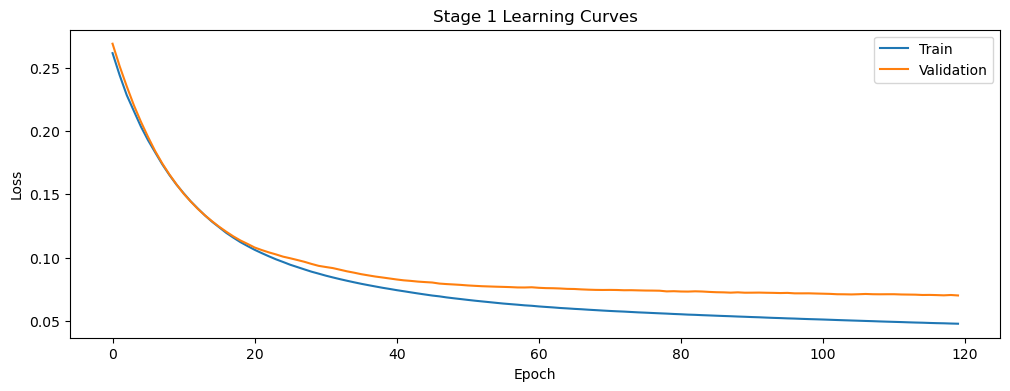

In [38]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12,4))
ax.plot(history_stage1.history["loss"], label="Train")
ax.plot(history_stage1.history["val_loss"], label="Validation")
ax.set_title("Stage 1 Learning Curves")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
plt.show()


In [39]:
eval_with_units(
    "Stage 1 Transfer Model - Real Test",
    transfer_model,
    x_real_test_s,
    y_real_test_s,
    scy,
    y_is_scaled=True,
    t_hit_in_seconds=True
)




Stage 1 Transfer Model - Real Test
target unit     MAE      RMSE  STD_abs_error
 x_hit   mm  75.326    97.191         61.418
 y_hit   mm  89.520   109.179         62.500
 z_hit   mm  42.253    54.415         34.289
vx_hit mm/s 372.541   581.875        446.981
vy_hit mm/s 336.721   453.677        304.043
vz_hit mm/s 861.561 1,042.926        587.714
 t_hit   ms  64.179    81.822         50.754


In [40]:
def snapshot_model(model):
    with tf.keras.utils.custom_object_scope({'weighted_mse': weighted_mse}):
        m = tf.keras.models.clone_model(model)
    m.set_weights(model.get_weights())
    return m

# --- run this RIGHT AFTER stage 1 training/eval ---
stage1_model = snapshot_model(transfer_model)
print("Saved stage1_model snapshot.")


Saved stage1_model snapshot.


In [41]:
# Stage 2: unfreeze all layers (tuned baseline)
for layer in transfer_model.layers:
    layer.trainable = True

transfer_model.compile(
    loss=weighted_mse,
    optimizer=Adam(learning_rate=5e-5),
    metrics=['mean_squared_error']
)

history_stage2 = transfer_model.fit(
    x_real_train_s, y_real_train_s,
    sample_weight=sample_w_real,
    validation_split=0.2,
    epochs=80,
    batch_size=16,
    verbose=1
)



Epoch 1/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.0479 - mean_squared_error: 0.1876 - val_loss: 0.0696 - val_mean_squared_error: 0.1143
Epoch 2/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0473 - mean_squared_error: 0.1869 - val_loss: 0.0700 - val_mean_squared_error: 0.1143
Epoch 3/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0470 - mean_squared_error: 0.1862 - val_loss: 0.0702 - val_mean_squared_error: 0.1143
Epoch 4/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0467 - mean_squared_error: 0.1857 - val_loss: 0.0703 - val_mean_squared_error: 0.1142
Epoch 5/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0464 - mean_squared_error: 0.1849 - val_loss: 0.0704 - val_mean_squared_error: 0.1140
Epoch 6/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0462 - mean_squared_error: 0.1844 - val_loss: 0.0704 - val_mean_squared_error: 0.1138
Epoch 7/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0459 - mean_squared_error: 0.1838 - val_loss: 0.0704 - val_mean_squared

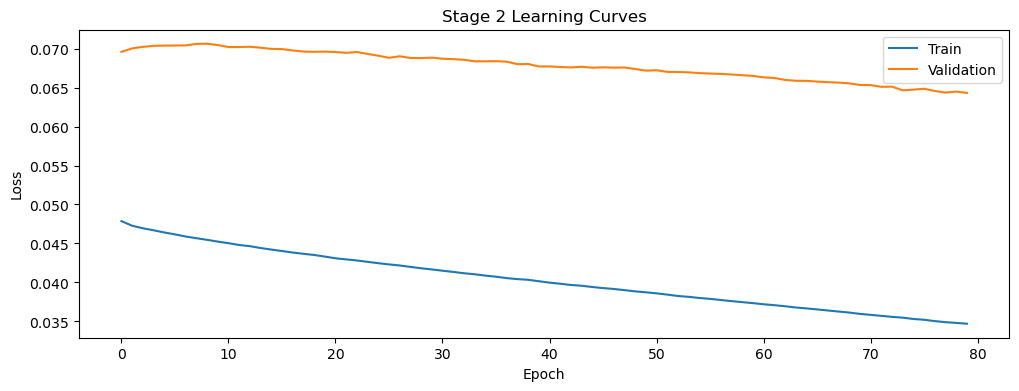

In [42]:
fig, ax = plt.subplots(figsize=(12,4))
ax.plot(history_stage2.history["loss"], label="Train")
ax.plot(history_stage2.history["val_loss"], label="Validation")
ax.set_title("Stage 2 Learning Curves")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
plt.show()


In [43]:
eval_with_units(
    "Stage 2 Final Transfer Model - Real Test",
    transfer_model,
    x_real_test_s,
    y_real_test_s,
    scy,
    y_is_scaled=True,
    t_hit_in_seconds=True
)




Stage 2 Final Transfer Model - Real Test
target unit     MAE    RMSE  STD_abs_error
 x_hit   mm  73.591  97.063         63.289
 y_hit   mm  89.855 110.615         64.512
 z_hit   mm  36.762  48.778         32.061
vx_hit mm/s 355.861 553.160        423.495
vy_hit mm/s 305.926 421.958        290.616
vz_hit mm/s 765.818 951.503        564.695
 t_hit   ms  57.041  71.658         43.373


In [44]:
stage2_model = snapshot_model(transfer_model)
print('Saved stage2_model snapshot.')

# Broad synthetic pretrained model snapshot
broad_model = snapshot_model(ball_predictor)
print('Saved broad_model snapshot.')

# Matched snapshot is optional (only if matched-training cells were run)
if 'transfer_model_matched' in globals():
    matched_model = snapshot_model(transfer_model_matched)
    print('Saved matched_model snapshot.')
else:
    matched_model = None
    print('No transfer_model_matched found in this run (broad-only flow).')



Saved stage2_model snapshot.
Saved broad_model snapshot.
No transfer_model_matched found in this run (broad-only flow).


In [45]:
# --- final comparison on real test set ---
eval_with_units('Broad model - Real Test', broad_model, x_real_test_s, y_real_test_s, scy, y_is_scaled=True, t_hit_in_seconds=True)

if matched_model is not None:
    eval_with_units('Matched model - Real Test', matched_model, x_real_test_s, y_real_test_s, scy, y_is_scaled=True, t_hit_in_seconds=True)
else:
    print('Matched model evaluation skipped (not trained in this notebook run).')

eval_with_units('Stage 1 model - Real Test', stage1_model, x_real_test_s, y_real_test_s, scy, y_is_scaled=True, t_hit_in_seconds=True)
eval_with_units('Stage 2 model - Real Test', stage2_model, x_real_test_s, y_real_test_s, scy, y_is_scaled=True, t_hit_in_seconds=True)




Broad model - Real Test
target unit       MAE      RMSE  STD_abs_error
 x_hit   mm   108.182   139.841         88.613
 y_hit   mm   100.509   130.873         83.819
 z_hit   mm    82.292   111.038         74.548
vx_hit mm/s   679.931   824.554        466.458
vy_hit mm/s 2,486.349 2,556.782        595.989
vz_hit mm/s 1,833.197 2,035.570        884.835
 t_hit   ms   167.846   197.336        103.774
Matched model evaluation skipped (not trained in this notebook run).

Stage 1 model - Real Test
target unit     MAE      RMSE  STD_abs_error
 x_hit   mm  75.326    97.191         61.418
 y_hit   mm  89.520   109.179         62.500
 z_hit   mm  42.253    54.415         34.289
vx_hit mm/s 372.541   581.875        446.981
vy_hit mm/s 336.721   453.677        304.043
vz_hit mm/s 861.561 1,042.926        587.714
 t_hit   ms  64.179    81.822         50.754

Stage 2 model - Real Test
target unit     MAE    RMSE  STD_abs_error
 x_hit   mm  73.591  97.063         63.289
 y_hit   mm  89.855 110.615   

## K-Fold Hyperparameter Tuning (Real Data)

Run this section after `transfer_model_matched`, `x_real`, `y_real`, `scx`, `scy`, `weighted_mse`, and `build_sample_weights` are defined.


In [ ]:
from sklearn.model_selection import KFold, ParameterGrid
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
import tensorflow as tf
import numpy as np
import pandas as pd


def clone_with_weights(model):
    with tf.keras.utils.custom_object_scope({'weighted_mse': weighted_mse}):
        m = tf.keras.models.clone_model(model)
    m.set_weights(model.get_weights())
    return m


# XYZ-only validation metric in scaled space (used for early stopping monitor)
def xyz_mse(y_true, y_pred):
    err2_xyz = tf.square(y_true[:, :3] - y_pred[:, :3])
    return tf.reduce_mean(err2_xyz, axis=-1)

# Make metric name deterministic in Keras history keys
xyz_mse.__name__ = 'xyz_mse'


def evaluate_physical_mae(model, x_val_s, y_val_s, y_scaler):
    y_pred_s = model.predict(x_val_s, verbose=0)
    y_true_u = y_scaler.inverse_transform(y_val_s)
    y_pred_u = y_scaler.inverse_transform(y_pred_s)
    mae = np.mean(np.abs(y_pred_u - y_true_u), axis=0)
    mae_ms = mae.copy()
    mae_ms[6] = mae_ms[6] * 1000.0
    return mae_ms


def run_transfer_kfold_once(x_real_raw, y_real_raw, base_model, hp, n_splits=5, seed=6):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    fold_rows = []

    for fold_id, (tr_idx, va_idx) in enumerate(kf.split(x_real_raw), start=1):
        x_tr, x_va = x_real_raw[tr_idx], x_real_raw[va_idx]
        y_tr, y_va = y_real_raw[tr_idx], y_real_raw[va_idx]

        x_tr_s = scx.transform(x_tr)
        x_va_s = scx.transform(x_va)
        y_tr_s = scy.transform(y_tr)
        y_va_s = scy.transform(y_va)

        sample_w = build_sample_weights(
            y_tr_s, scy, reachable_vec=np.ones(y_tr_s.shape[0], dtype=int)
        )

        model = clone_with_weights(base_model)

        freeze_first_n = int(hp.get('freeze_first_n', 2))
        for layer in model.layers[:freeze_first_n]:
            layer.trainable = False

        callbacks = [
            EarlyStopping(
                monitor='val_xyz_mse',
                patience=int(hp.get('patience', 12)),
                restore_best_weights=True,
                verbose=0,
                mode='min',
            )
        ]

        model.compile(
            loss=weighted_mse,
            optimizer=Adam(learning_rate=float(hp['stage1_lr'])),
            metrics=['mean_squared_error', xyz_mse],
        )
        hist1 = model.fit(
            x_tr_s,
            y_tr_s,
            sample_weight=sample_w,
            validation_data=(x_va_s, y_va_s),
            epochs=int(hp.get('stage1_epochs', 120)),
            batch_size=int(hp.get('batch_size', 16)),
            callbacks=callbacks,
            verbose=0,
        )
        best_stage1_xyz = float(np.min(hist1.history['val_xyz_mse']))

        stage2_epochs = int(hp.get('stage2_epochs', 80))
        if stage2_epochs > 0:
            for layer in model.layers:
                layer.trainable = True

            model.compile(
                loss=weighted_mse,
                optimizer=Adam(learning_rate=float(hp['stage2_lr'])),
                metrics=['mean_squared_error', xyz_mse],
            )
            hist2 = model.fit(
                x_tr_s,
                y_tr_s,
                sample_weight=sample_w,
                validation_data=(x_va_s, y_va_s),
                epochs=stage2_epochs,
                batch_size=int(hp.get('batch_size', 16)),
                callbacks=callbacks,
                verbose=0,
            )
            best_stage2_xyz = float(np.min(hist2.history['val_xyz_mse']))
            best_val_xyz_mse = min(best_stage1_xyz, best_stage2_xyz)
        else:
            best_val_xyz_mse = best_stage1_xyz

        mae = evaluate_physical_mae(model, x_va_s, y_va_s, scy)
        mae_xyz_mm = float(np.mean(mae[:3]))

        fold_rows.append(
            {
                'fold': fold_id,
                'best_val_xyz_mse': best_val_xyz_mse,
                'mae_x_mm': mae[0],
                'mae_y_mm': mae[1],
                'mae_z_mm': mae[2],
                'mae_xyz_mm': mae_xyz_mm,
                'mae_vx_mm_s': mae[3],
                'mae_vy_mm_s': mae[4],
                'mae_vz_mm_s': mae[5],
                'mae_t_ms': mae[6],
            }
        )

        tf.keras.backend.clear_session()

    return pd.DataFrame(fold_rows)


def run_grid_kfold(x_real_raw, y_real_raw, base_model, param_grid, n_splits=5, seed=6):
    all_runs = []

    for run_id, hp in enumerate(ParameterGrid(param_grid), start=1):
        fold_df = run_transfer_kfold_once(
            x_real_raw=x_real_raw,
            y_real_raw=y_real_raw,
            base_model=base_model,
            hp=hp,
            n_splits=n_splits,
            seed=seed,
        )

        summary = {
            'run_id': run_id,
            **hp,
            'mean_mae_xyz_mm': fold_df['mae_xyz_mm'].mean(),
            'std_mae_xyz_mm': fold_df['mae_xyz_mm'].std(ddof=0),
            'mean_best_val_xyz_mse': fold_df['best_val_xyz_mse'].mean(),
            'std_best_val_xyz_mse': fold_df['best_val_xyz_mse'].std(ddof=0),
            'mae_v_mm_s': fold_df[['mae_vx_mm_s', 'mae_vy_mm_s', 'mae_vz_mm_s']].mean().mean(),
            'mae_t_ms': fold_df['mae_t_ms'].mean(),
        }
        all_runs.append(summary)
        print(
            f"[run {run_id}] mean_mae_xyz_mm={summary['mean_mae_xyz_mm']:.2f} "
            f"mean_best_val_xyz_mse={summary['mean_best_val_xyz_mse']:.4f} hp={hp}"
        )

    out_df = pd.DataFrame(all_runs).sort_values(
        ['mean_mae_xyz_mm', 'mean_best_val_xyz_mse'],
        ascending=[True, True],
    ).reset_index(drop=True)
    return out_df



In [ ]:
# XYZ-focused ranking: results are sorted by mean_mae_xyz_mm
# K-fold hyperparameter search around your current best setup
# Current best baseline (from your last run):
# batch_size=16, freeze_first_n=2, patience=12, stage1_epochs=120, stage1_lr=1e-4, stage2_epochs=80, stage2_lr=5e-5
param_grid = {
    'freeze_first_n': [1,2],
    'stage1_lr': [1e-4, 1e-5],
    'stage2_lr': [5e-5, 3e-5],
    'batch_size': [16,32],
    'stage1_epochs': [50, 100],
    'stage2_epochs': [100, 150],
    'patience': [10],
}

kfold_results = run_grid_kfold(
    x_real_raw=x_real,
    y_real_raw=y_real,
    base_model=ball_predictor,
    param_grid=param_grid,
    n_splits=5,
    seed=6,
)

kfold_results.head(10)




In [46]:
from pathlib import Path
import joblib

export_dir = Path("../models/ann_stage2_big_dataset")
export_dir.mkdir(parents=True, exist_ok=True)

deploy_model = stage2_model   # or transfer_model / matched_model / broad_model
deploy_model.save(export_dir / "ball_predictor.keras")
joblib.dump(scx, export_dir / "scx.joblib")
joblib.dump(scy, export_dir / "scy.joblib")

print("Saved model + scalers to:", export_dir.resolve())


Saved model + scalers to: C:\Users\rocky\Personal\UBC\Year 4\IGEN 430\TableTennis_Software_Firmware\transfer_learning\models\ann_stage2_big_dataset
